# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment 01
## Data preprocessing, model training and evaluation

This lab assignment consists of several parts.

In this part you are supposed to work with tabular data: make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions in a chat, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

## 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [1]:
!pip install ucimlrepo

In [2]:
import ucimlrepo as uci
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [3]:
dataset = uci.fetch_ucirepo(id=149)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

Statlog (Vehicle Silhouettes) 

3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. 

The purpose is to classify a given silhouette as one of four types of vehicle, using  a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.  

HISTORY:

This data was originally gathered at the TI in 1986-87 by JP Siebert. It was partially financed by Barr and Stroud Ltd. The original purpose was to find a method of distinguishing 3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. Measures of shape features extracted from example silhouettes of objects to be discriminated were used to generate a classification rule tree by means of computer induction.

This object recognition strategy was successfully used to discriminate between silhouettes of model cars, vans and buses viewed from constrained elevati

In [4]:
data = dataset.data.features
target = dataset.data.targets

print(data.shape, target.shape)

(846, 18) (846, 1)


### 1.1 Data integrity

Check if data is valid. If it is not, remove invalid parts.


In [5]:
def clean_data(X, y):
    na_mask = X.isna().any(axis=1) | y.isna().any(axis=1)
    X, y = X[~na_mask], y[~na_mask]
    return X, y

X, y = clean_data(data, target)
print("Chean shapes:", data.shape, target.shape)

Chean shapes: (846, 18) (846, 1)


### 1.2 Train and test sets

Split data into 2 groups using `sklearn`'s infrastructure.

Which size of test set to choose?

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(676, 18) (676, 1) (169, 18) (169, 1)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [8]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
468,105.0,51,108,201,62,11,220,30,25,163,232,711,202,72,12,16,189,200
788,115.0,52,100,203,62,10,217,31,24,165,229,697,214,72,14,4,188,197
538,101.0,49,103,212,67,10,201,33,23,156,215,601,174,69,4,11,189,196
266,86.0,42,65,116,53,6,152,45,19,141,175,335,172,85,5,4,179,183
352,91.0,46,78,148,61,9,147,45,19,152,168,323,199,70,13,11,189,200
821,104.0,56,96,231,74,11,220,30,25,172,223,713,218,73,6,16,186,195
506,101.0,51,112,201,59,11,214,32,24,162,223,667,194,65,0,36,190,206
826,95.0,49,92,193,62,10,178,37,21,154,200,478,171,64,2,0,198,206
678,86.0,45,70,122,56,7,148,45,19,144,170,324,186,84,9,5,180,183
79,89.0,44,68,113,50,7,150,45,19,147,171,328,189,88,6,5,179,182


Methods `describe` and `info` deliver some useful information.

In [9]:
X_train_pd.describe()

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,93.683432,44.905325,82.072485,168.769231,61.656805,8.705621,168.650888,41.007396,20.568047,148.099112,188.328402,438.834320,174.755917,72.536982,6.313609,12.485207,188.866864,195.640533
std,8.202642,6.150693,15.874109,34.343709,8.343050,5.041225,33.225550,7.888948,2.580230,14.560238,31.394482,175.903338,32.353802,7.800672,4.839883,8.902339,6.209911,7.478923
min,73.000000,33.000000,42.000000,104.000000,47.000000,2.000000,114.000000,26.000000,17.000000,118.000000,131.000000,191.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,140.000000,57.000000,7.000000,146.750000,33.000000,19.000000,137.000000,167.000000,318.750000,150.000000,67.000000,2.000000,5.000000,184.000000,190.000000
50%,93.000000,44.000000,80.000000,166.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,365.000000,174.000000,72.000000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.250000,65.000000,10.000000,198.250000,46.000000,23.000000,160.000000,217.000000,590.500000,198.000000,75.250000,9.000000,18.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,59.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,204.000000,211.000000


In [10]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676 entries, 468 to 102
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   COMPACTNESS                       676 non-null    float64
 1   CIRCULARITY                       676 non-null    int64  
 2   DISTANCE CIRCULARITY              676 non-null    int64  
 3   RADIUS RATIO                      676 non-null    int64  
 4   PR.AXIS ASPECT RATIO              676 non-null    int64  
 5   MAX.LENGTH ASPECT RATIO           676 non-null    int64  
 6   SCATTER RATIO                     676 non-null    int64  
 7   ELONGATEDNESS                     676 non-null    int64  
 8   PR.AXIS RECTANGULARITY            676 non-null    int64  
 9   MAX.LENGTH RECTANGULARITY         676 non-null    int64  
 10  SCALED VARIANCE ALONG MAJOR AXIS  676 non-null    int64  
 11  SCALED VARIANCE ALONG MINOR AXIS  676 non-null    int64  
 12  SCALED RADI

## 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

### 2.0. Data preprocessing

Apply transformations to the dataset (if necessary).

Briefly explain the transformations

In [11]:
from sklearn.preprocessing import StandardScaler

x_sc = StandardScaler()
X_train = x_sc.fit_transform(X_train)
X_test = x_sc.transform(X_test)

В `data` представленны только числовые классы. Линейные модели крайне чувствительны к масштабу входных данных, и если не привести данные к одинаковому размеру (например, нулевому среднему и единичной дисперсии), то признаки с большими значениями начнут доминировать над признаками с меньшими значениями, что исказит геометрию нашей задачи. Поэтому перед обучением необходимо нормализовать данные с помощью `StandartScaler`.

In [12]:
from sklearn.preprocessing import LabelEncoder

y_le = LabelEncoder()
y_train = y_le.fit_transform(y_train.iloc[:, 0])
y_test = y_le.transform(y_test.iloc[:, 0])

В датасете `target` представлен одним из четырех категориальных классов (*saab, opel, bus или van*). Так как модель не может работать со строковыми классами, то перед обучением приведем `target` к числовому виду с помощью `LabelEncoder`.

### 2.1. Basic logistic regression

* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500
)

params = {
    "C": list(np.linspace(1e-3, 1e+2, 10))
}

grid = GridSearchCV(
    logreg,
    param_grid=params,
    scoring="f1_macro",
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 33.333999999999996}
Best score: 0.8025575340456857


In [14]:
from sklearn.metrics import accuracy_score, f1_score

best_model = grid.best_estimator_
best_C = grid.best_params_["C"]
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("Test accuracy:", acc)
print("Test macro-F1:", f1)

Test accuracy: 0.7869822485207101
Test macro-F1: 0.7798909037299131


<Figure size 720x576 with 0 Axes>

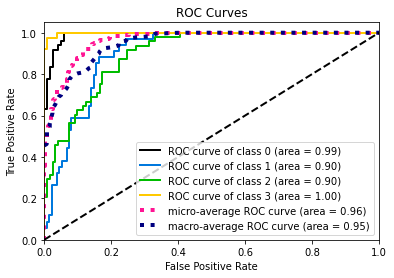

In [15]:
import matplotlib.pyplot as plt
import scikitplot as skplt

y_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
skplt.metrics.plot_roc(y_test, y_proba)
plt.show()

### 2.2. PCA: explained variance plot

Apply the PCA to the train part of the data.

Build the explaided variance plot.

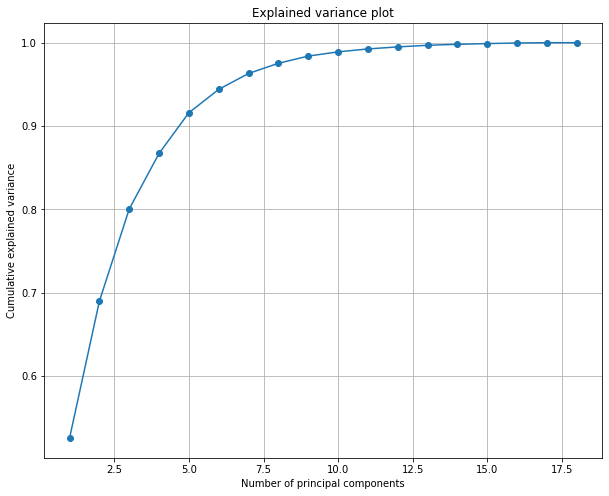

In [16]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train)

expl_var = pca.explained_variance_ratio_
cum_expl_var = np.cumsum(expl_var)

plt.figure(figsize=(10, 8))
plt.plot(range(1, len(expl_var) + 1), cum_expl_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance plot")
plt.grid(True)
plt.show()

### 2.3. PCA trasformation

Select the appropriate number of components.

Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train`, `val` and `test` parts.*

In [17]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

Возьмем столько компонент у PCA, чтобы отсечь лишь самые неинформативные компоненты, которые имеют наименьшую дисперсию. Возьмём порог в 95%. Нормализовать данные при использовании метода главных компонент необходимо, так как этот метод основан на разложении ковариационной матрицы и поэтому чувствителен к масштабу данных --- большие данные будут давать большую дисперсию.

Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.

### 2.4. Logistic regression on PCA-preprocessed data

* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.
* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

In [18]:
from sklearn.pipeline import Pipeline

logreg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500
)

pipe = Pipeline([
    ("pca", pca),
    ("logreg", logreg),
])

params = {
    "logreg__C": list(np.linspace(1e-3, 1e+2, 10))
}

grid = GridSearchCV(
    pipe,
    param_grid=params,
    scoring="f1_macro",
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'logreg__C': 22.223}
Best score: 0.6212255958096102


In [19]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("Test accuracy:", acc)
print("Test macro-F1:", f1)

Test accuracy: 0.650887573964497
Test macro-F1: 0.6367798867798868


<Figure size 720x576 with 0 Axes>

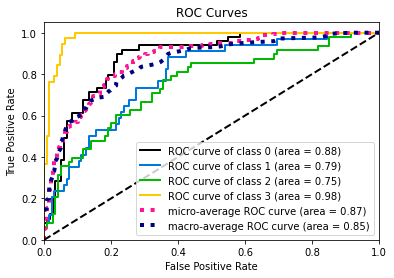

In [20]:
y_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
skplt.metrics.plot_roc(y_test, y_proba)
plt.show()

### 2.5. Decision tree

* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

params = {
    "max_depth": list(range(1, 21))
}

grid = GridSearchCV(
    estimator=dt,
    param_grid=params,
    scoring="f1_macro",
    verbose=1
)

grid.fit(X_train, y_train)
print("Best max_depth:", grid.best_params_)
print("Best CV F1_macro:", grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best max_depth: {'max_depth': 8}
Best CV F1_macro: 0.6995953268392527


In [22]:
best_dt = grid.best_estimator_
best_depth = grid.best_params_["max_depth"]
y_pred = best_dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("Test accuracy:", acc)
print("Test macro-F1:", f1)

Test accuracy: 0.7633136094674556
Test macro-F1: 0.7601306340822039


### 2.6. Bagging

Here starts the ensembling part. You need to use [BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ with step 5.

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

In [23]:
from sklearn.ensemble import BaggingClassifier

Ns = list(range(2, 101, 5))

logreg_base = LogisticRegression(
    C=best_C,
    multi_class="multinomial",
    solver="saga",
    tol=1e-3,
    max_iter=500,
    random_state=42
)

tree_base = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

def eval_bagging(base_estimator, X_train, y_train, X_test, y_test, bootstrap=True):
    acc, f1 = [], []
    for N in Ns:
        bag = BaggingClassifier(
            estimator=base_estimator,
            n_estimators=N,
            bootstrap=bootstrap,
            random_state=42
        )
        
        bag.fit(X_train, y_train)
        y_pred = bag.predict(X_test)
        acc.append(accuracy_score(y_test, y_pred))
        f1.append(f1_score(y_test, y_pred, average="macro"))
    return np.array(acc), np.array(f1)

logreg_acc, logreg_f1 = eval_bagging(logreg_base, X_train, y_train, X_test, y_test)
tree_acc, tree_f1 = eval_bagging(tree_base, X_train, y_train, X_test, y_test)


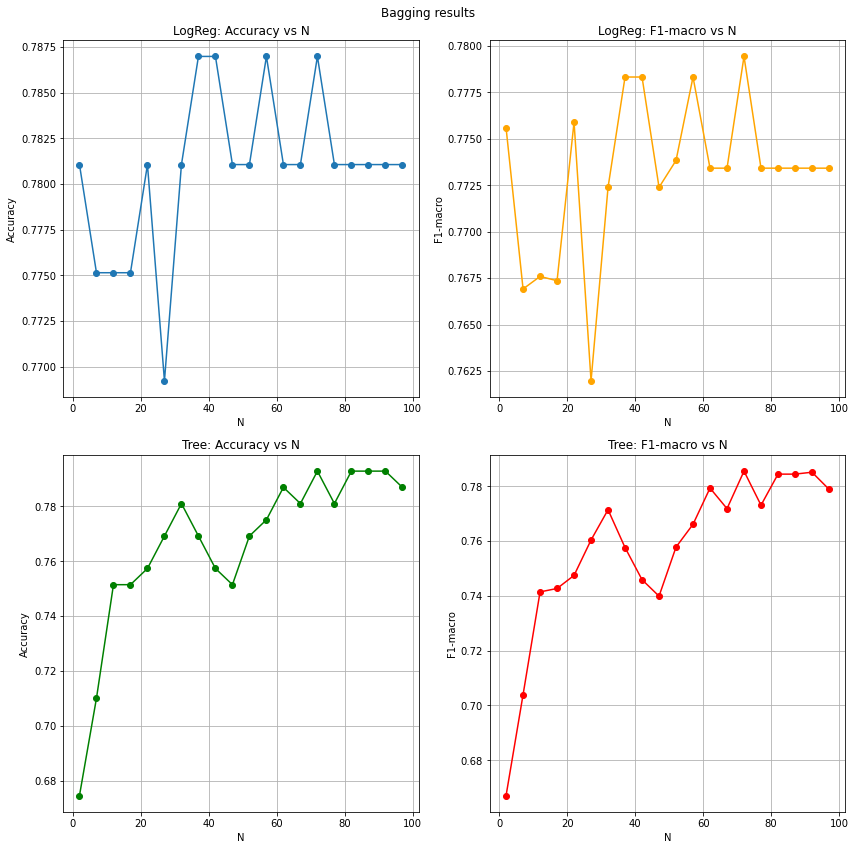

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Bagging results")

axes[0, 0].plot(Ns, logreg_acc, marker='o')
axes[0, 0].set_title("LogReg: Accuracy vs N")
axes[0, 0].set_xlabel("N")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].grid(True)

axes[0, 1].plot(Ns, logreg_f1, marker='o', color='orange')
axes[0, 1].set_title("LogReg: F1-macro vs N")
axes[0, 1].set_xlabel("N")
axes[0, 1].set_ylabel("F1-macro")
axes[0, 1].grid(True)

axes[1, 0].plot(Ns, tree_acc, marker='o', color='green')
axes[1, 0].set_title("Tree: Accuracy vs N")
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].grid(True)

axes[1, 1].plot(Ns, tree_f1, marker='o', color='red')
axes[1, 1].set_title("Tree: F1-macro vs N")
axes[1, 1].set_xlabel("N")
axes[1, 1].set_ylabel("F1-macro")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

На графиках accuracy и f1-score для логистической регрессии видно, что у метрик небольшой разброс и все они близки к среднему. Наилучшим результатом можно считать $N \approx 40$ Это можно объяснить тем, что логистическая регрессия сама по себе имеет низкую дисперсию, поэтому эффект бэггинга дает не такой большой вклад, как с деревьями $-$ небольшого количества моделей уже достаточно, чтобы получить максимальный эффект.

Обе метрики accuracy и f1-score практически монотонно растут и после $N \approx 60$ выходят на плато, где прирост замедляется. Так как одиночное дерево $-$ это метод с высокой дисперсией, то увеличение размера ансамбля сильно снижает эту дисперсию, но после большого количества моделей эффекта уже практически не привносит

Тот `max_depth`, который был найден в пункте 2.5 не обязательно является оптимальным для ансамбля, так как `max_depth` для одиночного дерева является оптимумом в соотношении между средним и дисперсией для одного дерева, а в ансамбле `max_depth` можно выбрать больше, чтобы повысить дисперсию каждого дерева, а затем получить больший выигрыш от усреднения всех деревьев.

### 2.7. Random Forest

Now we will work with the [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

* Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

In [25]:
from sklearn.ensemble import RandomForestClassifier

n_trees = list(range(5, 205, 5))

acc, f1 = [], []
for n in n_trees:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred, average="macro"))
    
best_n = n_trees[np.argmax(acc)]
print("Best tree number:", best_n)

Best tree number: 40


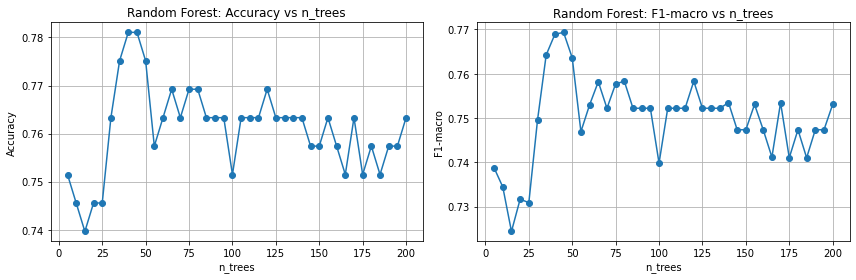

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(n_trees, acc, marker="o")
axes[0].set_title("Random Forest: Accuracy vs n_trees")
axes[0].set_xlabel("n_trees")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)

axes[1].plot(n_trees, f1, marker="o")
axes[1].set_title("Random Forest: F1-macro vs n_trees")
axes[1].set_xlabel("n_trees")
axes[1].set_ylabel("F1-macro")
axes[1].grid(True)

plt.tight_layout()
plt.show()

На обоих графиках видно, что оптимальное число деревьев для `Random Forest` находится в районе $N \approx 40$. После этого значения виден только спад и выход метрик на плато.

Оптимальное количество деревьев для `Random Forest` ($N = 40$) оказывается ниже оптимального количества деревьев для бэггинга ($N = 60$). Это можно объяснить тем, что метод `Random Forest` представляет собой комбинацию методов `Bagging` и `Random Subspace` (где каждое дерево обучается на случайном подмножестве признаков). Такая дополнительная случайность уменьшает корреляцию деревьев и позволяет достичь уровня замеделения роста при меньшем количестве деревьев.

### 2.8. Learning curve

Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected. First train it on first part, then on first and second parts combined (so the train size in increased by 2 times), first 3 parts and so on.

* You may use `sklearn`'s [readymade function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html). But note that you need to adjust parameters of this function appropriately.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score vs dataset size).

* Analyse the final plot. Can you make any conlusions using it?

In [27]:
n_parts = 10
sizes = np.linspace(0.1, 1.0, n_parts)
indices = np.arange(len(X_train))

lr_model = LogisticRegression(
    C=best_C,
    multi_class="multinomial",
    solver="saga",
    tol=1e-3,
    max_iter=500,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=best_n,
    random_state=42
)

models = {
    "LogReg": lr_model,
    "DecisionTree": dt_model,
    "RandomForest": rf_model
}

acc = {name: [] for name in models}
f1 = {name: [] for name in models}
train_sizes = []
for frac in sizes:
    k = int(len(X_train) * frac)
    train_sizes.append(k)
    
    X_sub = X_train[:k]
    y_sub = y_train[:k]
    
    for name, model in models.items():
        model.fit(X_sub, y_sub)
        y_pred = model.predict(X_test)
        acc[name].append(accuracy_score(y_test, y_pred))
        f1[name].append(f1_score(y_test, y_pred, average="macro"))

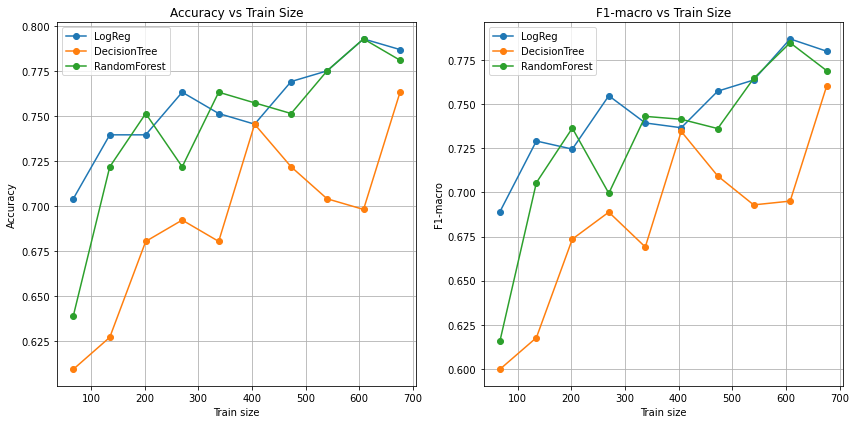

In [28]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for name in models:
    plt.plot(train_sizes, acc[name], marker="o", label=name)
plt.title("Accuracy vs Train Size")
plt.xlabel("Train size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for name in models:
    plt.plot(train_sizes, f1[name], marker="o", label=name)
plt.title("F1-macro vs Train Size")
plt.xlabel("Train size")
plt.ylabel("F1-macro")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

* `Logistic Regression` стабильно растет при увеличении данных. Уже при количестве данных $\approx 50\%$ приближается к итоговому значению точности. Флуктуации небольшие, так как это модель с низкой дисперсией.
* `Decision Tree` на маленьких выборках даёт самое низкое качество. При увеличении количества данных качество дерева растет быстро, но очень нестабильно.
* `Random Forest` на малом объёме данных показывает себя хуже логистической регрессии, но быстро растёт при увеличении данных. Кривая довольно гладкая, так как ансамбль снижает дисперсию.

### 2.9. Boosting

Apply [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) to this problem.

Find optimal hyperparameters using [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) or RandomizedSearchCV.

Hyperparameters to consider:
* depth of each tree
* number of decision trees
* learning rate

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)

params = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [1, 2, 3, 4]
}

grid = GridSearchCV(
    estimator=gbc,
    param_grid=params,
    scoring="f1_macro",
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best f1_macro:", grid.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best f1_macro: 0.7692100956021422


In [30]:
gbc_best = grid.best_estimator_
y_pred = gbc_best.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("Test accuracy:", acc)
print("Test macro-F1:", f1)

Test accuracy: 0.7633136094674556
Test macro-F1: 0.7578947368421053
